# Logistic Regression

In the last example, both $x$ and $y$ were continuous variables (their values ranged from $-\infty$ to $\infty$).  What if our output variable is binary?  That is, suppose the output variable can take only one of two values, 0 or 1, and so we need a classification model.

Let's create a dataset which has 3 continuous features, and a target variable with 2 classes:

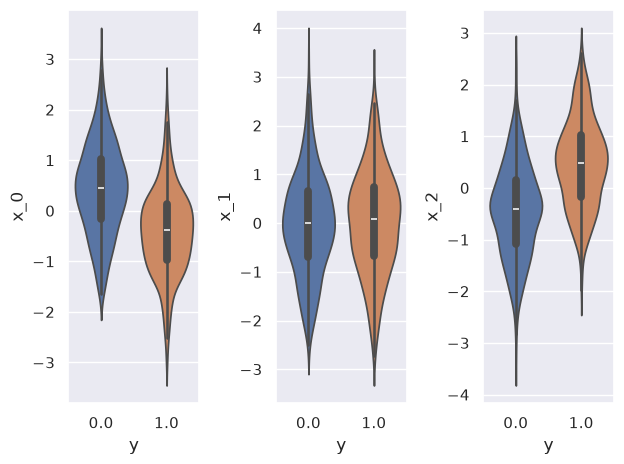

In [1]:
# Imports
import probflow as pf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Settings
N = 1000 #number of datapoints
D = 3    #number of features

# Generate data
rand = lambda *x: np.random.rand(*x).astype('float32')
randn = lambda *x: np.random.randn(*x).astype('float32')
x = randn(N, D)
w = np.array([[2.], [0.1], [-2.]]).astype('float32')
noise = randn(N, 1)
logistic_fn = lambda x: 1.0 / (1.0 + np.exp(-x))
true_p = logistic_fn(x @ w + noise)
sample_p = rand(N, 1)
y = (sample_p > true_p).astype('float32')

# Plot it
for i in range(D):
    plt.subplot(1, D, i+1)
    sns.violinplot(x=y[:, 0], y=x[:, i], hue=y[:, 0], legend=False)
    plt.xlabel("y")
    plt.ylabel(f"x_{i}")
plt.tight_layout()
plt.show()

## Building a Logistic Regression Manually

A logistic regression is a model where our output variable is categorical. It’s basically the same thing as a linear regression, except we pipe the linearly predicted value through a nonlinear function to get the probability of the output class:

$$
p(y=1) = f( \mathbf{x}^\top \mathbf{w} + b )
$$

where $f$ is usually the
[logistic function](https://en.wikipedia.org/wiki/Logistic_function).  Or,
with $>2$ classes, a
[softmax](<https://en.wikipedia.org/wiki/Softmax_function).

If our target variable has only 2 possible classes, we can model this using a
[Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution):

$$
y \sim \text{Bernoulli}( f( \mathbf{x}^\top \mathbf{w} + b ) )
$$

To create this model in ProbFlow, we'll create a class which inherits
`CategoricalModel`, because the target variable is categorical
(either 0 or 1).  Again, in the `__init__` method we define the parameters
of the model, and in the `__call__` method we compute probabilistic
predictions given the parameters and the input data:

In [2]:
class LogisticRegression(pf.CategoricalModel):

    def __init__(self, dims):
        """Initialize the logistic regression's parameters."""
        self.w = pf.Parameter([dims, 1], name='Weights')
        self.b = pf.Parameter([1, 1], name='Bias')

    def __call__(self, x):
        """Forward pass of the logistic regression."""
        return pf.Bernoulli(x @ self.w() + self.b())

Note that by default, the `pf.Bernoulli` distribution treats its inputs as logits (that is, it passes the inputs through a sigmoid function to get the output class probabilities). To force it to treat the inputs as raw probability values, use the `probs` keyword argument to the `Bernoulli` constructor.

Then we can instantiate our model class,

In [3]:
model = LogisticRegression(D)

I0000 00:00:1789865917.428867    3179 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789865917.429600    3179 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789865917.494614    3179 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789865919.042216    3179 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

And fit it to the data!

In [4]:
model.fit(x, y, lr=0.01)

Now we can plot the posterior distributions for the weights and the bias, and can see that the model recovered the values we used to generate the data:

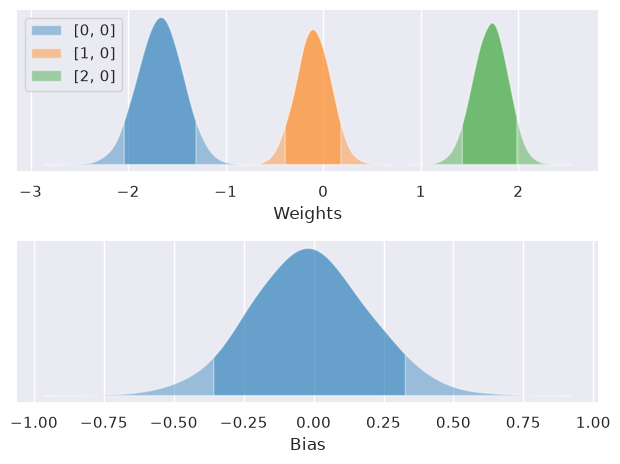

In [5]:
model.posterior_plot(ci=0.9)

## Using the LogisticRegression module

An even easier way to do a logistic regression with ProbFlow is to use the pre-built `LogisticRegression` model:

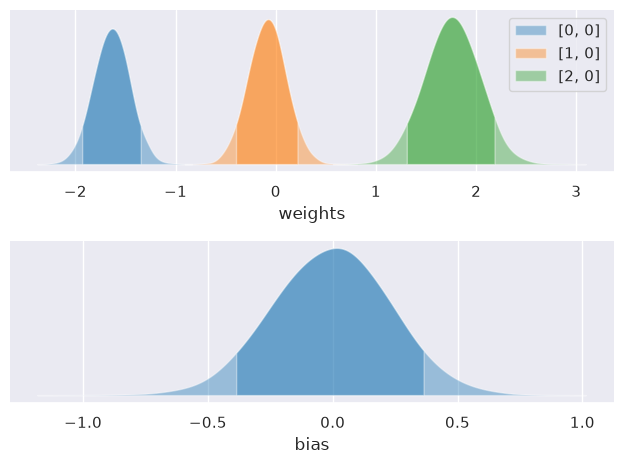

In [6]:
model = pf.LogisticRegression(D)
model.fit(x, y, lr=0.01)
model.posterior_plot(ci=0.9)

## Multinomial Logistic Regression

The `LogisticRegression` model even handles when $y$ has multiple classes (that is, a [Multinomial logistic regression](https://en.wikipedia.org/wiki/Multinomial_logistic_regression)). Let’s generate some data with 4 features, where the target has 3 possible classes:

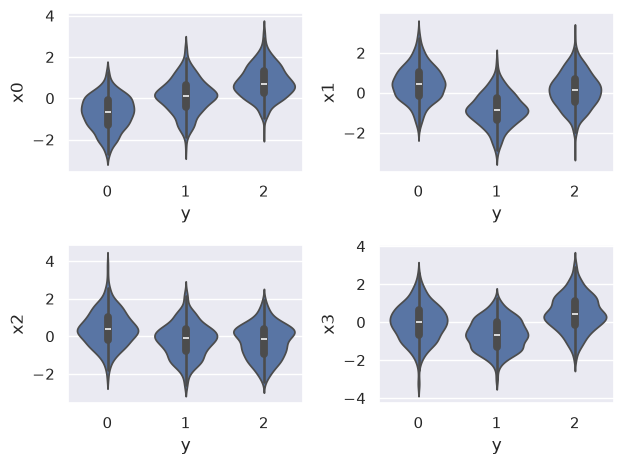

In [7]:
# Settings
N = 1000  # number of datapoints
D = 4  # number of features
K = 3  # number of target classes

# Generate data
x = randn(N, D)
w = 2 * randn(D, K)
noise = 0.1 * randn(N, 1)
softmax_fn = lambda x: np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)
true_p = softmax_fn(x @ w + noise)
sample_p = rand(N, 1)
y = np.argmax(np.cumsum(true_p, axis=1) > sample_p, axis=1, keepdims=True)

# Plot it
for i in range(D):
    plt.subplot(2, 2, i+1)
    sns.violinplot(x=y[:, 0], y=x[:, i], legend=False)
    plt.xlabel("y")
    plt.ylabel(f"x{i}")
plt.tight_layout()
plt.show()

The `k` keyword argument to `LogisticRegression` sets the number of classes of the dependent variable.

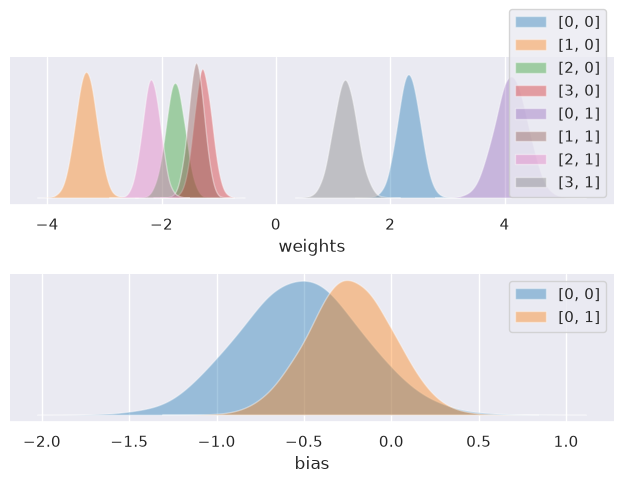

In [8]:
model = pf.LogisticRegression(D, k=K)
model.fit(x, y, lr=0.01, epochs=200)
model.posterior_plot()

And we can predict the target class given the features:

In [9]:
model.predict(x[:5, :])

array([2, 2, 2, 2, 2], dtype=int32)

Or even compute the posterior predictive probability of the target class for test datapoints:

E0000 00:00:1789865933.175463    3179 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


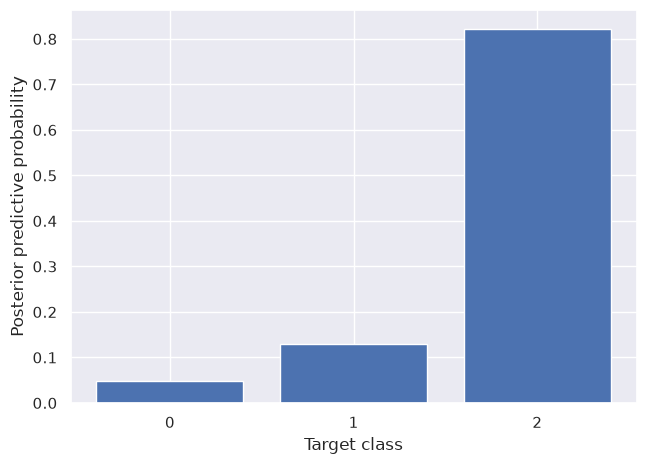

In [10]:
x_test = randn(1, D)
model.pred_dist_plot(x_test)
plt.xlabel("Target class")
plt.ylabel("Posterior predictive probability")
plt.show()